<a href="https://colab.research.google.com/github/pranav-1205/CSL701-Roll_No_CS47_Machine-Learning-Lab/blob/main/Experiments/Experiment_03_Multiple_Linear_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

 Name : Pranav Vivek Sadwelkar

 Roll No : 47 Batch: CS-03

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [88]:
df = pd.read_csv("car_data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

First 5 rows:
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petrol            Manual    17.00    1197      80.00      5   
3  Individual    Petrol            Manual    20.92     998      67.10      5   
4      Dealer    Diesel            Manual    22.77    1498      98.59      5   

   selling_price  
0         120000  
1         550000

## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [89]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [90]:
features = [
    "vehicle_age",
    "km_driven",
    "seller_type",
    "fuel_type",
    "transmission_type",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

df_model = df[features + ["selling_price"]].copy()

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [91]:
df_model = pd.get_dummies(
    df_model,
    columns=[
        "seller_type",
        "fuel_type",
        "transmission_type"
    ],
    drop_first=True,
    dtype=int
)

print(df_model.head())

   vehicle_age  km_driven  mileage  engine  max_power  seats  selling_price  \
0            9     120000    19.70     796      46.30      5         120000   
1            5      20000    18.90    1197      82.00      5         550000   
2           11      60000    17.00    1197      80.00      5         215000   
3            9      37000    20.92     998      67.10      5         226000   
4            6      30000    22.77    1498      98.59      5         570000   

   seller_type_Individual  seller_type_Trustmark Dealer  fuel_type_Diesel  \
0                       1                             0                 0   
1                       1                             0                 0   
2                       1                             0                 0   
3                       1                             0                 0   
4                       0                             0                 1   

   fuel_type_Electric  fuel_type_LPG  fuel_type_Petrol  \
0   

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [92]:
print(df[["vehicle_age"]].head(10))

   vehicle_age
0            9
1            5
2           11
3            9
4            6
5            8
6            8
7            3
8            2
9            4


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

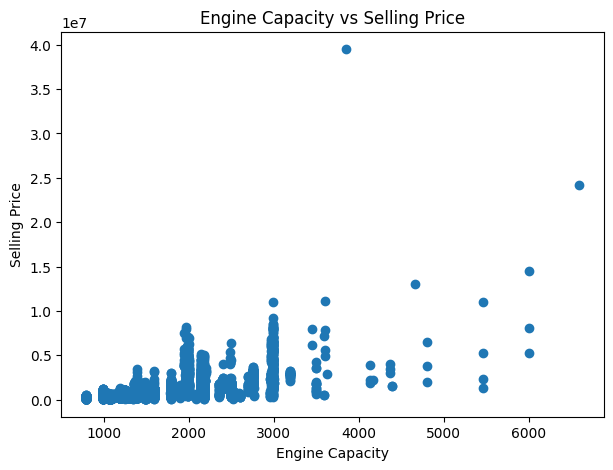

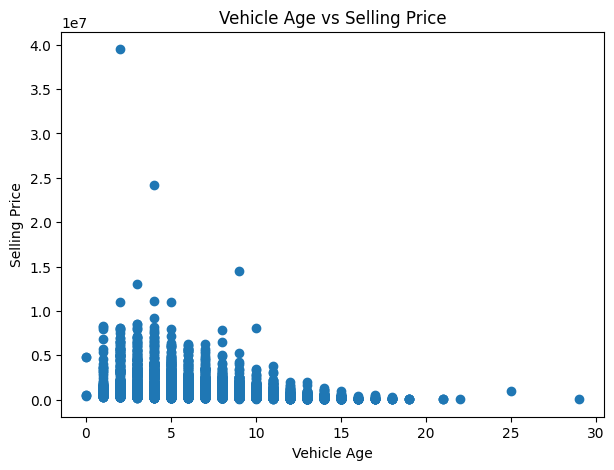

In [93]:
# Graph 1 — Engine vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    df["engine"],
    df["selling_price"]
)

plt.xlabel("Engine Capacity")
plt.ylabel("Selling Price")
plt.title("Engine Capacity vs Selling Price")

plt.show()

# Graph 2 — Vehicle Age vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    df["vehicle_age"],
    df["selling_price"]
)

plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")

plt.show()

#Observation
The Engine vs Selling Price scatter plot is used to observe whether vehicles with larger engine capacities tend to have higher selling prices. The Vehicle Age vs Selling Price plot helps observe how vehicle age is related to resale price.

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [94]:
numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [95]:
np.random.seed(42)

n = len(df_model)

indices = np.random.permutation(n)

train_size = int(0.8 * n)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_data = df_model.iloc[train_indices].copy()
test_data = df_model.iloc[test_indices].copy()

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))


# Task 8 Part 2: Standardization
train_mean = train_data[numerical_features].mean()
train_std = train_data[numerical_features].std()

train_data[numerical_features] = (
    train_data[numerical_features] - train_mean
) / train_std

test_data[numerical_features] = (
    test_data[numerical_features] - train_mean
) / train_std

print("Standardization completed.")
print(train_data.head())

Training samples: 12328
Testing samples: 3083
Standardization completed.
       vehicle_age  km_driven   mileage    engine  max_power     seats  \
3334      1.976751   0.317719  0.160192 -0.555738  -0.505706 -0.402974   
10928    -0.673248   0.042354  1.844911 -0.457339  -0.620337 -0.402974   
2518      0.320502   0.739946  0.258447 -0.457339  -0.275039  2.067371   
11322    -1.666997  -0.939781 -0.309517  0.025010   0.440588 -0.402974   
9394      1.645501   0.115785  0.002025 -1.329426  -1.268356 -0.402974   

       selling_price  seller_type_Individual  seller_type_Trustmark Dealer  \
3334          190000                       0                             0   
10928         600000                       1                             0   
2518          665000                       0                             0   
11322        1570000                       0                             0   
9394          160000                       0                             0   

       fuel_t

## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [96]:
feature_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

categorical_columns = [
    col for col in train_data.columns
    if col.startswith("seller_type_")
    or col.startswith("fuel_type_")
    or col.startswith("transmission_type_")
]

feature_columns += categorical_columns

X_train = train_data[feature_columns].to_numpy(dtype=float)
y_train = train_data["selling_price"].to_numpy(dtype=float)

X_test = test_data[feature_columns].to_numpy(dtype=float)
y_test = test_data["selling_price"].to_numpy(dtype=float)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12328, 13)
y_train shape: (12328,)
X_test shape: (3083, 13)
y_test shape: (3083,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [97]:
X_train_bias = np.column_stack(
    (np.ones(X_train.shape[0]), X_train)
)

X_test_bias = np.column_stack(
    (np.ones(X_test.shape[0]), X_test)
)

print("X_train_bias shape:", X_train_bias.shape)
print("X_test_bias shape:", X_test_bias.shape)

X_train_bias shape: (12328, 14)
X_test_bias shape: (3083, 14)


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [98]:
def ols(X, y):
    XT = X.T
    XTX = XT @ X
    XTy = XT @ y

    beta = np.linalg.inv(XTX) @ XTy

    return beta

beta = ols(X_train_bias, y_train)

print("Beta coefficients:")
print(beta)

Beta coefficients:
[ 994217.80724364 -195171.00645712  -34966.44421261   62399.82523068
   48023.76608771  644359.63397446    6812.45062217   -6783.55536347
  -78002.67281776 -124692.42956251  -96756.41053173  358735.63796481
 -119859.21560938 -121450.23037614]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [99]:
XTX = X_train_bias.T @ X_train_bias

det = np.linalg.det(XTX)

print("Determinant:", det)

if np.isclose(det, 0):
    print("Matrix is singular or nearly singular.")
else:
    print("Matrix is not singular.")

Determinant: 4.026727295259044e+43
Matrix is not singular.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [100]:
beta = ols(X_train_bias, y_train)

print("Intercept:", beta[0])

print("\nFeature Coefficients:")

for feature, coefficient in zip(feature_columns, beta[1:]):
    print(f"{feature}: {coefficient:.6f}")

Intercept: 994217.8072436415

Feature Coefficients:
vehicle_age: -195171.006457
km_driven: -34966.444213
mileage: 62399.825231
engine: 48023.766088
max_power: 644359.633974
seats: 6812.450622
seller_type_Individual: -6783.555363
seller_type_Trustmark Dealer: -78002.672818
fuel_type_Diesel: -124692.429563
fuel_type_Electric: -96756.410532
fuel_type_LPG: 358735.637965
fuel_type_Petrol: -119859.215609
transmission_type_Manual: -121450.230376


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [101]:
for feature, coefficient in zip(feature_columns, beta[1:]):

    if coefficient > 0:
        direction = "Positive"
    else:
        direction = "Negative"

    print(
        f"{feature}: {coefficient:.4f} -> {direction}"
    )

# Find larger coefficients
importance = sorted(
zip(feature_columns, np.abs(beta[1:])),
key=lambda x: x[1],
reverse=True
)

print("\nFeature influence:")

for feature, value in importance:
    print(f"{feature}: {value:.4f}")

vehicle_age: -195171.0065 -> Negative
km_driven: -34966.4442 -> Negative
mileage: 62399.8252 -> Positive
engine: 48023.7661 -> Positive
max_power: 644359.6340 -> Positive
seats: 6812.4506 -> Positive
seller_type_Individual: -6783.5554 -> Negative
seller_type_Trustmark Dealer: -78002.6728 -> Negative
fuel_type_Diesel: -124692.4296 -> Negative
fuel_type_Electric: -96756.4105 -> Negative
fuel_type_LPG: 358735.6380 -> Positive
fuel_type_Petrol: -119859.2156 -> Negative
transmission_type_Manual: -121450.2304 -> Negative

Feature influence:
max_power: 644359.6340
fuel_type_LPG: 358735.6380
vehicle_age: 195171.0065
fuel_type_Diesel: 124692.4296
transmission_type_Manual: 121450.2304
fuel_type_Petrol: 119859.2156
fuel_type_Electric: 96756.4105
seller_type_Trustmark Dealer: 78002.6728
mileage: 62399.8252
engine: 48023.7661
km_driven: 34966.4442
seats: 6812.4506
seller_type_Individual: 6783.5554


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [102]:
y_pred = X_test_bias @ beta

print("Actual vs Predicted:")

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(
        f"Actual: {actual:.2f} | "
        f"Predicted: {predicted:.2f}"
    )

Actual vs Predicted:
Actual: 4450000.00 | Predicted: 2046440.49
Actual: 1290000.00 | Predicted: 1431417.81
Actual: 485000.00 | Predicted: 339097.18
Actual: 400000.00 | Predicted: 543268.20
Actual: 800000.00 | Predicted: 862352.98
Actual: 150000.00 | Predicted: -616511.22
Actual: 650000.00 | Predicted: 820935.00
Actual: 325000.00 | Predicted: -175814.55
Actual: 300000.00 | Predicted: 378640.92
Actual: 925000.00 | Predicted: 776919.73


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [103]:
residuals = y_test - y_pred

RSS = np.sum(residuals ** 2)

print("RSS:", RSS)

RSS: 885105657669987.2


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [104]:
y_mean = np.mean(y_test)

TSS = np.sum(
    (y_test - y_mean) ** 2
)

R2 = 1 - (RSS / TSS)

print("TSS:", TSS)
print("RSS:", RSS)
print("R²:", R2)

TSS: 2407385049859876.5
RSS: 885105657669987.2
R²: 0.6323373123375069


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


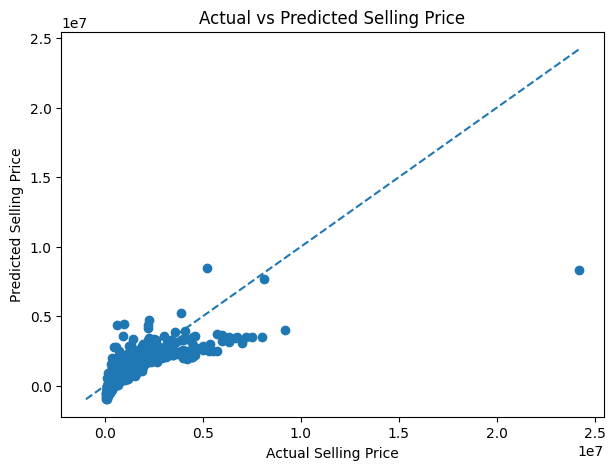

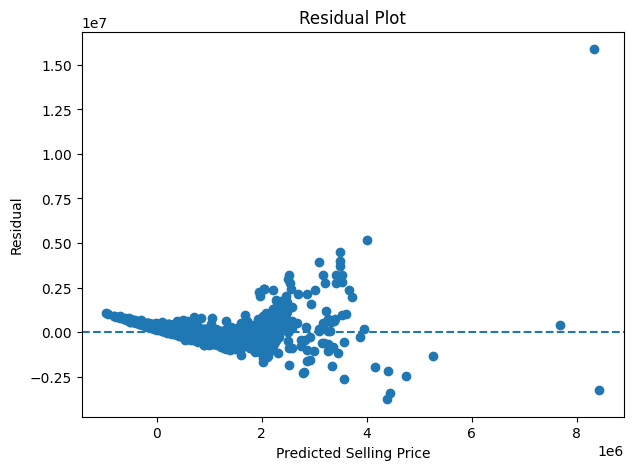

Largest prediction errors:
Actual = 6645000.00, Predicted = 3412467.57, Error = 3232532.43
Actual = 5200000.00, Predicted = 8434192.83, Error = -3234192.83
Actual = 999000.00, Predicted = 4439604.79, Error = -3440604.79
Actual = 7199000.00, Predicted = 3488916.56, Error = 3710083.44
Actual = 625000.00, Predicted = 4390873.61, Error = -3765873.61
Actual = 7000000.00, Predicted = 3084722.09, Error = 3915277.91
Actual = 7500000.00, Predicted = 3485713.74, Error = 4014286.26
Actual = 8000000.00, Predicted = 3488916.56, Error = 4511083.44
Actual = 9200000.00, Predicted = 4009019.39, Error = 5190980.61
Actual = 24200000.00, Predicted = 8323205.42, Error = 15876794.58


In [105]:
# Graph 3 — Actual vs Predicted
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

# Graph 4 — Residual Plot
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

# Find Largest Prediction Errors
absolute_errors = np.abs(residuals)

largest = np.argsort(absolute_errors)[-10:]

print("Largest prediction errors:")

for i in largest:
    print(
        f"Actual = {y_test[i]:.2f}, "
        f"Predicted = {y_pred[i]:.2f}, "
        f"Error = {residuals[i]:.2f}"
    )

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
In this experiment, Multiple Linear Regression was implemented from scratch using NumPy matrix operations and the Ordinary Least Squares (OLS) method. The CarDekho used-car dataset was preprocessed by checking missing values, selecting relevant features, encoding categorical variables using dummy variables, and using the available `vehicle_age` feature. The dataset was divided into 80% training and 20% testing data, and numerical features were standardized using statistics calculated from the training data.

The regression coefficients were calculated using the OLS equation, β̂ = (XᵀX)⁻¹Xᵀy. The trained model was then used to predict selling prices for the test data. Model performance was evaluated using Residual Sum of Squares (RSS) and R². The obtained RSS was **[enter your RSS value]**, while the R² value was **[enter your R² value]**.

The coefficient analysis helped identify the features having relatively greater influence on the predicted selling price. Multiple Linear Regression is simple, interpretable, and computationally efficient. However, it assumes approximately linear relationships and can be affected by outliers, multicollinearity, and nonlinear relationships in real-world used-car prices.

Overall, the experiment demonstrates how Multiple Linear Regression can be implemented, trained, evaluated, and interpreted without using a ready-made regression algorithm.
